# 08 – Qualitative analysis
Run a battery of qualitative checks (confusion matrices, top‑errors, per‑class reports) for every trained model in the experiment.

👉 **Before running:** make sure the experiment folder contains a `predictions/` directory with `<model>_preds.csv` files.

In [1]:
# -------------------------------------------------------------
# Common pre‑amble – read config & export core variables
# -------------------------------------------------------------

from pathlib import Path
import os, sys

# infer repo root from the location of this file
repo_root = os.path.abspath('..')
sys.path.insert(0, str(repo_root))  # allow `import src.*`
from config.notebook_setup import *

Repository Root: /home/marcmaceira/projects/reuters-rag-classifier_clean
Configuration: {'general': {'run_name': 'experiment_with_13_classes', 'seed': 42, 'n_classes': 13}, 'dataset': {'split_type': 'test', 'test_split': 0.2, 'cutoff_year': 1996}, 'paths': {'data_exploration_dir': 'experiment_with_13_classes/data_exploration', 'artifacts_dir': 'experiment_with_13_classes/artifacts', 'embeddings_dir': 'experiment_with_13_classes/embeddings', 'models_dir': 'experiment_with_13_classes/models', 'results_dir': 'experiment_with_13_classes/results'}, 'model': {'embedding_backend': 'sbert', 'sbert_model_name': 'sentence-transformers/all-MiniLM-L12-v2', 'openai_model_name': 'text-embedding-3-small', 'classifier': 'linear_svm', 'rag_top_k': 5, 'use_llm_refine': False}, 'training': {'batch_size': 32, 'max_epochs': 10, 'learning_rate': '1e-3'}, 'evaluation': {'metrics': ['accuracy', 'macro_f1', 'auc_ovr']}}

=== Configuration Variables ===

[DATASET]
  DATASET_CUTOFF_YEAR: 1996
  DATASET_SPLIT_TYP

In [2]:
from pathlib import Path
import pandas as pd
import os
import glob
import shutil

# Using paths from loaded configuration
EXPERIMENT_DIR = Path(PATHS_RESULTS_DIR).parent  # Parent of results directory is the experiment root
MODELS_DIR = Path(PATHS_MODELS_DIR)
OUTPUT_DIR = Path(PATHS_DATA_EXPLORATION_DIR) / "qualitative_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Create a predictions directory
PREDICTIONS_DIR = EXPERIMENT_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Find model directories
model_dirs = [d for d in MODELS_DIR.glob('*') if d.is_dir()]

if model_dirs:
    print(f"Found {len(model_dirs)} model directories. Creating prediction files...")
    
    # For each model directory, get the test predictions file and copy/transform for qualitative analysis
    for model_dir in model_dirs:
        model_name = model_dir.name
        test_pred_file = model_dir / "test_predictions.csv"
        
        if test_pred_file.exists():
            # Read the predictions file
            df = pd.read_csv(test_pred_file)
            
            # Rename columns if necessary to match expected names
            if 'y_true' in df.columns and 'y_pred' in df.columns:
                df = df.rename(columns={
                    'y_true': 'true_label',
                    'y_pred': 'pred_label'
                })
            
            # If we need to add text column (which might be required by qualitative_analysis)
            # We'll just add a placeholder - the actual implementation would need to get the text from somewhere
            if 'text' not in df.columns:
                # In a real scenario, you would join with a dataset containing the text
                # This is just a placeholder to make the qualitative_analysis script work
                df['text'] = "Placeholder text"
            
            # Add an ID column if it doesn't exist
            if 'id' not in df.columns:
                df['id'] = range(len(df))
            
            # Save to predictions directory with the expected naming convention
            output_file = PREDICTIONS_DIR / f"{model_name}_preds.csv"
            df.to_csv(output_file, index=False)
            print(f"  Created prediction file for {model_name}")
    
    # Now run the qualitative analysis
    from src.qualitative_analysis import run_all_qualitative_analyses
    
    # Check if we have prediction files
    pred_files = glob.glob(str(PREDICTIONS_DIR / '*_preds.csv'))
    if pred_files:
        print(f"Running qualitative analysis with {len(pred_files)} prediction files")
        run_all_qualitative_analyses(EXPERIMENT_DIR, OUTPUT_DIR, top_n=20)
    else:
        print("No prediction files were created. Please check if the model result directories contain the necessary data.")
else:
    print("No model directories found.")

Found 8 model directories. Creating prediction files...
  Created prediction file for RAG-kMajority
  Created prediction file for Naive Bayes
  Created prediction file for RAG-LLM (OpenAI-embeddings)
  Created prediction file for MiniLM + LogReg
  Created prediction file for RAG-CentroidNN
  Created prediction file for RAG-LLM (local-embeddings)
  Created prediction file for TF-IDF bigrams + SVM
  Created prediction file for Linear SVM
Running qualitative analysis with 8 prediction files
▶ MiniLM + LogReg
▶ RAG-CentroidNN
▶ RAG-LLM (OpenAI-embeddings)
▶ TF-IDF bigrams + SVM
▶ RAG-LLM (local-embeddings)


/home/marcmaceira/projects/reuters-rag-classifier_clean/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marcmaceira/projects/reuters-rag-classifier_clean/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marcmaceira/projects/reuters-rag-classifier_clean/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

▶ Naive Bayes
▶ RAG-kMajority
▶ Linear SVM
✔︎ Qualitative artefacts saved to /home/marcmaceira/projects/reuters-rag-classifier_clean/experiment_with_13_classes/data_exploration/qualitative_outputs


In [3]:
# preview one of the error CSVs
import glob, pandas as pd, os
some_csvs = glob.glob(str(OUTPUT_DIR / '*_top20_errors.csv'))
if some_csvs:
    print('Preview:', os.path.basename(some_csvs[0]))
    display(pd.read_csv(some_csvs[0]).head())
else:
    print('No error CSVs found – perhaps the earlier cell needs to run first.')


Preview: MiniLM + LogReg_top20_errors.csv


,true_label,pred_label,text,id
0,earn,crude,Placeholder text,3
1,crude,ship,Placeholder text,13
2,crude,acq,Placeholder text,15
3,crude,ship,Placeholder text,16
4,interest,money-supply,Placeholder text,22


Analyzing classification errors from /home/marcmaceira/projects/reuters-rag-classifier_clean/experiment_with_13_classes...
Running enhanced qualitative analysis...
Loaded 8 model prediction files
Analyzing error patterns...
Identifying consistently misclassified examples...
Analyzing text features...
Creating visualizations...
Generating detailed error report...
✓ Enhanced qualitative analysis complete. Results saved to /home/marcmaceira/projects/reuters-rag-classifier_clean/experiment_with_13_classes/data_exploration/qualitative_outputs
Loaded 8 model prediction files

Top 10 Common Error Patterns:


,error_type,total_count
0,grain → corn,18
1,dlr → money-fx,15
2,money-fx → interest,12
3,money-fx → dlr,9
4,interest → money-supply,8
5,crude → ship,8
6,corn → sugar,8
7,interest → money-fx,8
8,ship → crude,8
9,grain → ship,7



Found 32 examples misclassified by multiple models
Top misclassified examples:


,id,text,true_label,misclassified_count,models,predictions
3,16,Placeholder text,crude,8,"MiniLM + LogReg, RAG-CentroidNN, RAG-LLM (Open...","ship, ship, trade, money-fx, trade, money-fx, ..."
4,22,Placeholder text,interest,8,"MiniLM + LogReg, RAG-CentroidNN, RAG-LLM (Open...","money-supply, money-supply, money-fx, money-su..."
13,46,Placeholder text,corn,8,"MiniLM + LogReg, RAG-CentroidNN, RAG-LLM (Open...","sugar, sugar, sugar, sugar, sugar, sugar, suga..."
6,28,Placeholder text,money-fx,7,"MiniLM + LogReg, RAG-CentroidNN, TF-IDF bigram...","dlr, dlr, trade, trade, trade, dlr, trade"
9,36,Placeholder text,grain,7,"MiniLM + LogReg, RAG-CentroidNN, TF-IDF bigram...","corn, corn, corn, corn, corn, corn, corn"
10,37,Placeholder text,grain,7,"MiniLM + LogReg, RAG-CentroidNN, RAG-LLM (Open...","ship, ship, ship, ship, ship, ship, ship"
7,29,Placeholder text,money-fx,7,"MiniLM + LogReg, RAG-CentroidNN, TF-IDF bigram...","interest, interest, interest, trade, interest,..."
1,13,Placeholder text,crude,6,"MiniLM + LogReg, RAG-CentroidNN, TF-IDF bigram...","ship, ship, ship, ship, ship, ship"
11,39,Placeholder text,grain,6,"MiniLM + LogReg, RAG-CentroidNN, TF-IDF bigram...","corn, corn, corn, corn, corn, corn"
8,35,Placeholder text,trade,6,"MiniLM + LogReg, RAG-CentroidNN, RAG-LLM (loca...","dlr, dlr, corn, dlr, dlr, dlr"


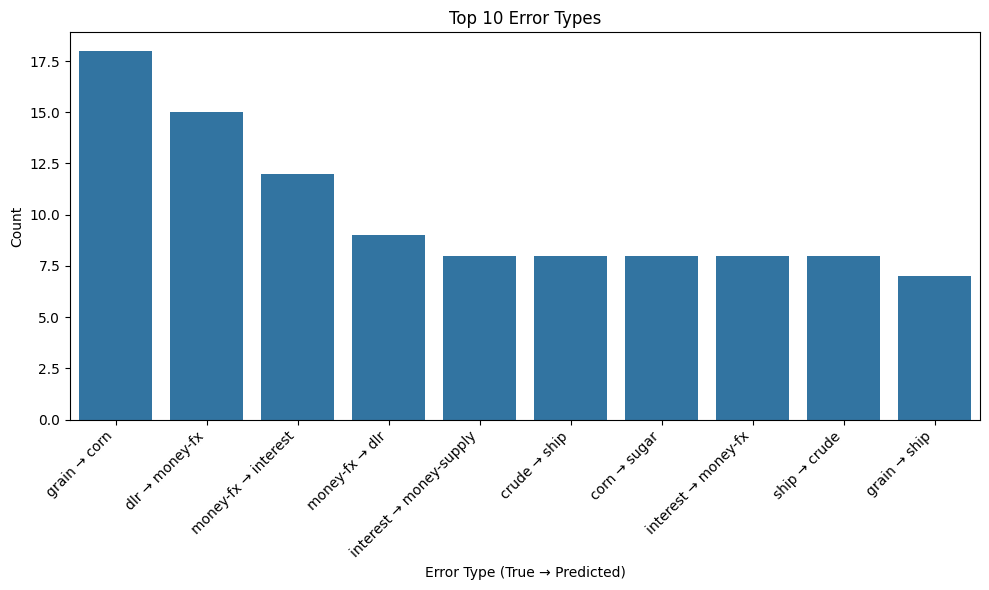

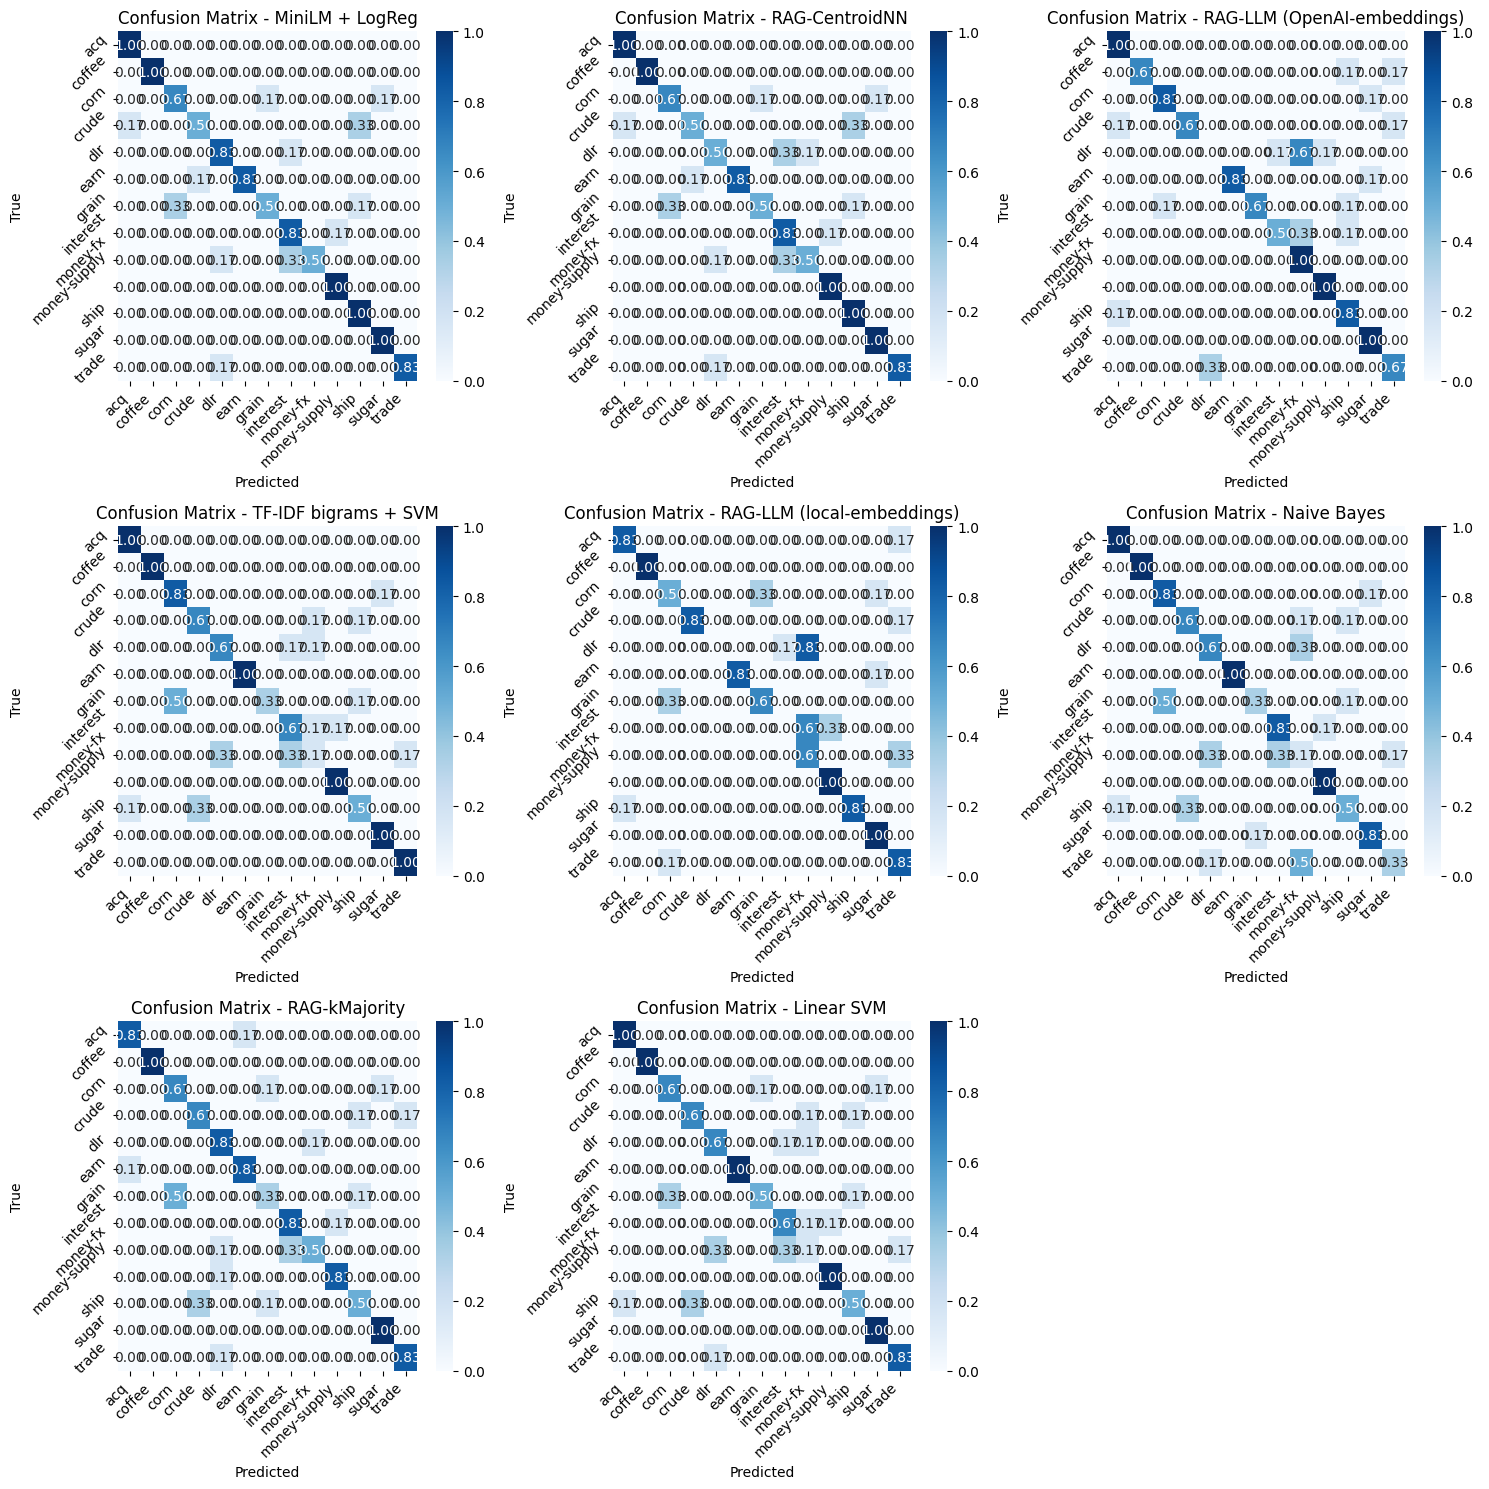

Misclassification analysis by true label:


,true_label,count,avg_misclassified_models,avg_text_length,avg_word_count
2,dlr,6,3.833333,16.0,2.0
6,money-fx,5,5.200000,16.0,2.0
4,grain,5,5.000000,16.0,2.0
7,ship,3,4.666667,16.0,2.0
1,crude,3,5.666667,16.0,2.0
8,trade,3,3.333333,16.0,2.0
5,interest,3,4.666667,16.0,2.0
0,corn,2,6.500000,16.0,2.0
3,earn,2,2.500000,16.0,2.0


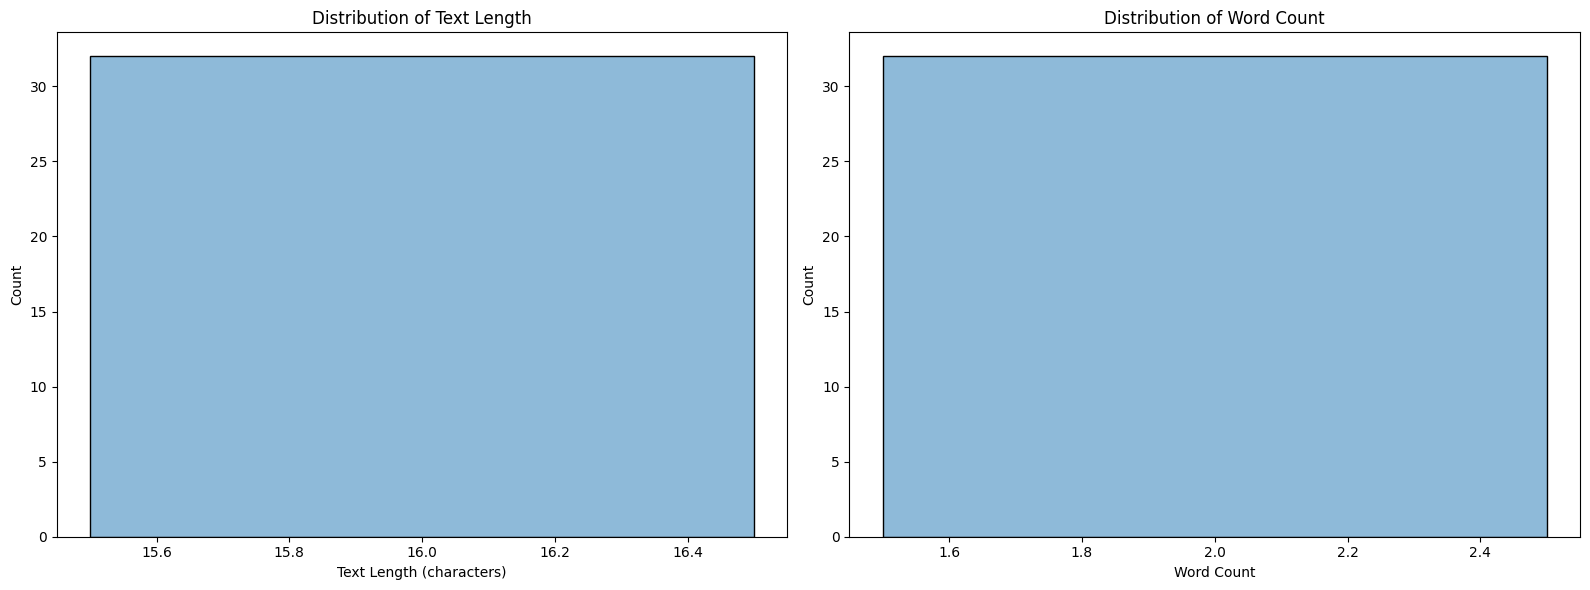


Correlation between text characteristics and misclassification:


,text_length,word_count,misclassified_count
text_length,NaN,NaN,NaN
word_count,NaN,NaN,NaN
misclassified_count,NaN,NaN,1.0


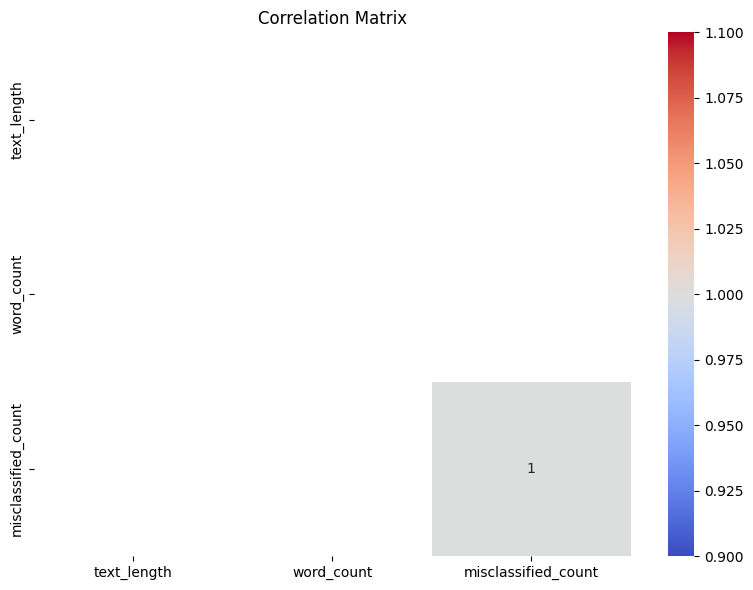


Detailed analysis saved to /home/marcmaceira/projects/reuters-rag-classifier_clean/experiment_with_13_classes/data_exploration/qualitative_outputs
Open /home/marcmaceira/projects/reuters-rag-classifier_clean/experiment_with_13_classes/data_exploration/qualitative_outputs/detailed_error_report.html for a complete error analysis report


In [4]:
from src.enhanced_qualitative_analysis import run_enhanced_qualitative_analysis


# Run the enhanced qualitative analysis
print(f"Analyzing classification errors from {EXPERIMENT_DIR}...")
results = run_enhanced_qualitative_analysis(EXPERIMENT_DIR, OUTPUT_DIR)

# For interactive exploration in notebook, import these functions
from notebooks.error_analysis import analyze_errors, plot_confusion_matrices, analyze_text_characteristics

# Get more detailed analysis with visualizations
detailed_results = analyze_errors(EXPERIMENT_DIR, interactive=True)

# Generate confusion matrices for all models
plot_confusion_matrices(EXPERIMENT_DIR)

# Analyze text characteristics of misclassified examples
if not detailed_results['misclassified_examples'].empty:
    analyze_text_characteristics(detailed_results['misclassified_examples'])
else:
    print("No consistently misclassified examples found.")

print(f"\nDetailed analysis saved to {OUTPUT_DIR}")
print(f"Open {OUTPUT_DIR}/detailed_error_report.html for a complete error analysis report")